In [271]:
import matplotlib.pyplot as plt
import torch

N = 10_000

x = torch.randint(1, 7, (N,))
x[:20]

tensor([5, 6, 6, 3, 5, 3, 5, 3, 2, 2, 6, 5, 3, 6, 2, 5, 1, 2, 5, 1])

In [272]:
counts = torch.bincount(x, minlength=7)[1:]
counts, counts.sum()

(tensor([1610, 1695, 1695, 1677, 1675, 1648]), tensor(10000))

In [273]:
counts / N

tensor([0.1610, 0.1695, 0.1695, 0.1677, 0.1675, 0.1648])

In [274]:
(counts / N).sum()

tensor(1.)

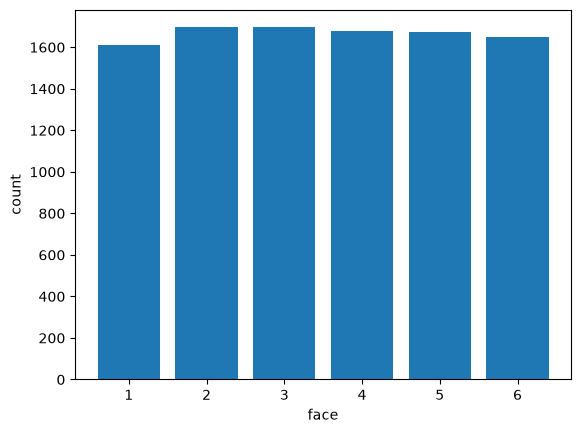

In [275]:
plt.bar(range(1, 7), counts)
plt.xlabel("face")
plt.ylabel("count");

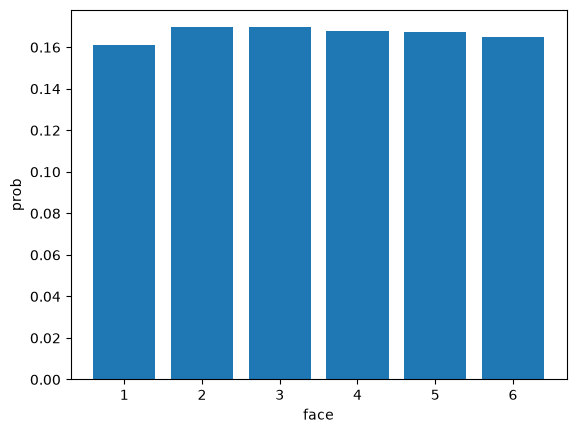

In [276]:
probs = counts / N
plt.bar(range(1, 7), probs)
plt.xlabel("face")
plt.ylabel("prob");

In [277]:
1 / 6

0.16666666666666666

In [278]:
x = torch.rand(N)
print(x[:5])
torch.unique(x).numel(), N


tensor([0.6744, 0.3526, 0.5825, 0.9435, 0.9209])


(9999, 10000)

In [279]:
edges = torch.linspace(0, 1, 11)  # 10 bins => 11 edges
idx = torch.bucketize(x, edges[1:-1])  # which bin each sample lands in
counts = torch.bincount(idx, minlength=10)
counts


tensor([ 975,  992, 1063,  984, 1030, 1038, 1013,  984,  951,  970])

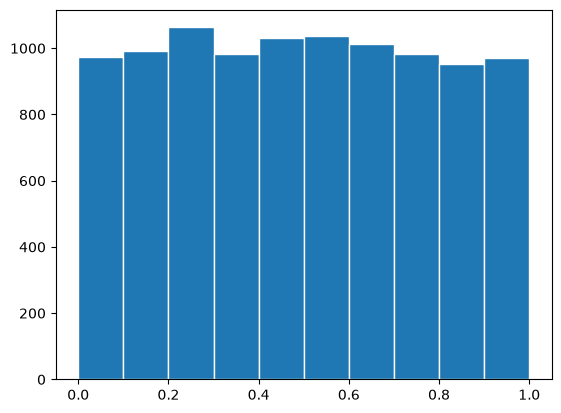

In [280]:
plt.hist(x, bins=10, edgecolor="white");


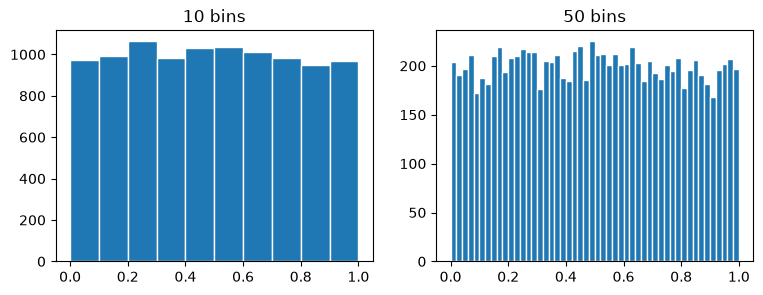

In [281]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(x, bins=10, edgecolor="white")
ax[0].set_title("10 bins")
ax[1].hist(x, bins=50, edgecolor="white")
ax[1].set_title("50 bins");


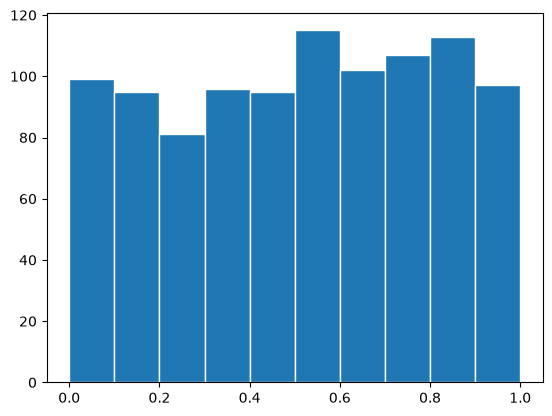

In [282]:
N = 1000
x = torch.rand(N)

plt.hist(x, bins=10, edgecolor="white")
plt.show()

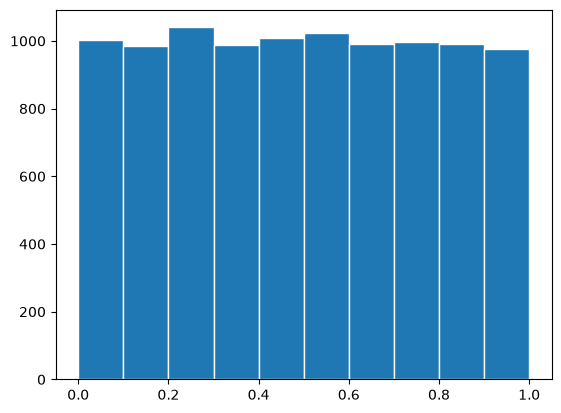

In [283]:
N = 10000
x = torch.rand(N)

plt.hist(x, bins=10, edgecolor="white")
plt.show()

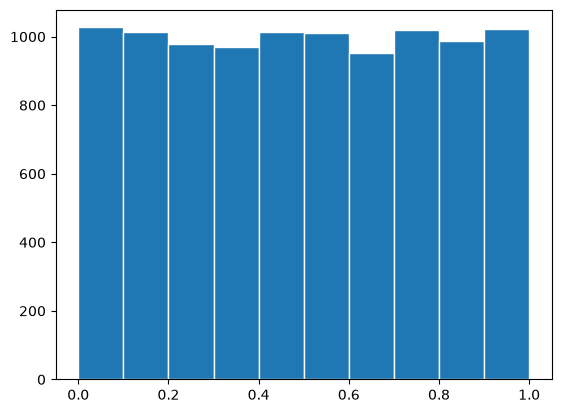

In [284]:
N = 10000
x = torch.rand(N)
edges = torch.linspace(0, 1, 11)

idx = torch.bucketize(x, edges[1:-1], right=True)
counts = torch.bincount(idx, minlength=10)

plt.bar(edges[:-1], counts, width=edges[1] - edges[0], align="edge", edgecolor="white")
plt.ylim(0, None)
plt.show()

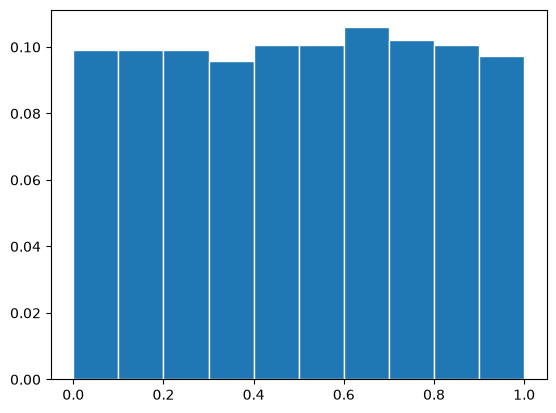

In [285]:
N = 10000
x = torch.rand(N)
edges = torch.linspace(0, 1, 11)

idx = torch.bucketize(x, edges[1:-1], right=True)
counts = torch.bincount(idx, minlength=10)
probs = counts / N
plt.bar(edges[:-1], probs, width=edges[1] - edges[0], align="edge", edgecolor="white")
plt.ylim(0, None)
plt.show()

width=tensor(0.0500)
(density * width).sum()=tensor(1.0000)


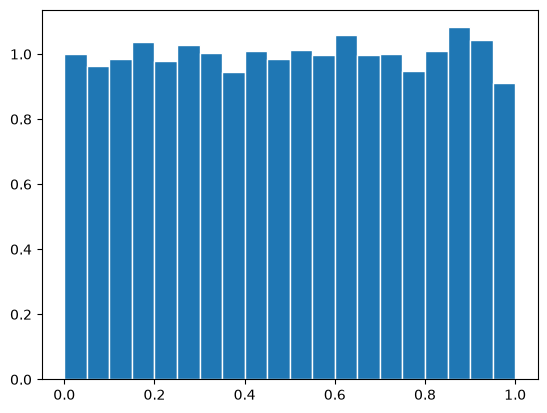

In [286]:
N = 10000
x = torch.rand(N)
bins = 20
edges = torch.linspace(0, 1, bins + 1)

idx = torch.bucketize(x, edges[1:-1], right=True)
counts = torch.bincount(idx, minlength=bins)
probs = counts / N
width = edges[1] - edges[0]
print(f"{width=}")
density = probs / width
print(f"{(density * width).sum()=}")
plt.bar(edges[:-1], density, width=width, align="edge", edgecolor="white")
plt.ylim(0, None)
plt.show()

In [287]:
width = 1 / 50
edges = torch.linspace(0, 1, 51)
counts = torch.bincount(torch.bucketize(x, edges[1:-1]), minlength=50)
density = counts / (N * width)
density[:10]


tensor([0.9400, 1.0550, 0.9300, 0.9850, 1.0000, 0.9550, 1.0950, 0.9300, 1.0100,
        1.0700])

In [ ]:
(density * width).sum()

tensor(1.0000)